<a href="https://colab.research.google.com/github/NANDINI-NANDY123/Play2donate-/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
import numpy as np
import os,cv2
def plot_gallery(images,titles,h,w,n_rows=3,n_col=4):
    plt.figure(figsize=(1.8*n_col,2.4*n_rows)) # Corrected n_row to n_rows
    plt.subplots_adjust(bottom=0,left=.01,right=.99,top=.90,hspace=.35)
    for i in range(n_rows*n_col):
        plt.subplot(n_rows,n_col,i+1)
        # Check if the image array is 2D (tabular data) or 3D (image data)
        if len(images.shape) == 2:
            # If tabular, we need to reshape it for imshow.
            # This assumes h and w are appropriate dimensions for visualization.
            # We'll use gray as default for consistency, but it might not be meaningful.
            if images[i].shape[0] == h*w:
                plt.imshow(images[i].reshape((h,w)),cmap=plt.cm.gray)
            else:
                # If the number of features doesn't match h*w,
                # we cannot reshape it into a square image.
                # For tabular data, image plotting is often not applicable.
                # Display text or skip plotting image if not suitable.
                plt.text(0.5, 0.5, 'N/A', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
        else:
            # If it's already image data (e.g., from fetch_lfw_people), plot directly
            plt.imshow(images[i],cmap=plt.cm.gray)
        plt.title(titles[i],size=12)
        plt.xticks(())
        plt.yticks(())

In [2]:
import numpy as np
from sklearn.datasets import fetch_lfw_people

# Download the LFW dataset if not already on disk
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# introspect the images to find the shapes (width and height)
n_samples, h, w = lfw_people.images.shape

# for machine learning we use the data directly (as relative pixel
# position info is ignored by this model)
X = lfw_people.data
n_features = X.shape[1]

# the label to predict is the id of the person
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]
class_names = target_names.tolist() # Ensure class_names is populated for later use

print("Total dataset size:")
print("n_samples: %d" % n_samples)
print("n_features: %d" % n_features)
print("n_classes: %d" % n_classes)

Total dataset size:
n_samples: 1288
n_features: 1850
n_classes: 7


In [3]:
# This cell was used for checking a directory path, which is not relevant for the LFW dataset.
# import os
# path_to_check =r"C:\Users\majji pujitha\OneDrive\Desktop\test_lyst1717074532669.csv"
# print(f"Listing contents of directory: {path_to_check}")
# if os.path.isdir(path_to_check):
#     try:
#         for item in os.listdir(path_to_check):
#             print(item)
#     except Exception as e:
#         print(f"An error occurred while listing directory: {e}")
# else:
#     print(f"Error: Directory '{path_to_check}' not found or is not a directory.")
#     print("Please ensure you have uploaded your dataset and provided the correct path.")

Extracting the top 150 eigenfaces from 966 faces


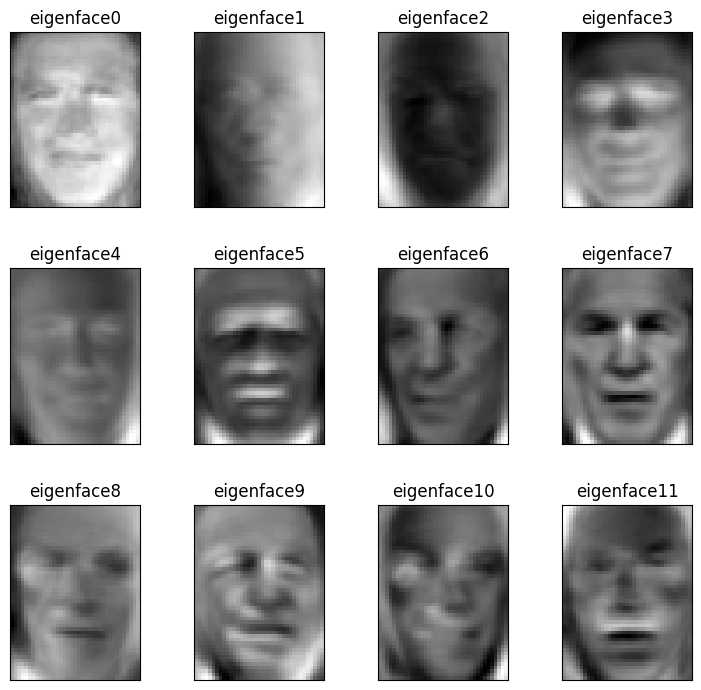

X_train_pca.shape (966, 150)
X_test_pca.shape (322, 150)
Project done...


In [4]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42)
n_components=150 # Reverted n_components to a common value for LFW
print("Extracting the top %d eigenfaces from %d faces"% (n_components,X_train.shape[0]))

pca=PCA(n_components=n_components,svd_solver='randomized',whiten=True).fit(X_train)
eigenfaces=pca.components_.reshape((n_components,h,w)) # Uncommented
eigenface_titles=["eigenface%d"% i for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces,eigenface_titles,h,w)
plt.show()

X_train_pca=pca.transform(X_train)
X_test_pca=pca.transform(X_test)
print("X_train_pca.shape",X_train_pca.shape)
print("X_test_pca.shape",X_test_pca.shape)
lda=LinearDiscriminantAnalysis()
lda.fit(X_train_pca,y_train)
X_train_lda=lda.transform(X_train_pca)
X_test_lda=lda.transform(X_test_pca)
print("Project done...")

In [5]:
# Re-initialize MLPClassifier to ensure it picks up correct input features from X_train_lda
clf = MLPClassifier(random_state=1, hidden_layer_sizes=(10, 10), max_iter=1000, verbose=True)
clf.fit(X_train_lda, y_train)
print("Model Weights:")
model_info = [coef.shape for coef in clf.coefs_]
print(model_info)

Iteration 1, loss = 2.06284934
Iteration 2, loss = 2.00288220
Iteration 3, loss = 1.94706503
Iteration 4, loss = 1.89359365
Iteration 5, loss = 1.84227255
Iteration 6, loss = 1.79379700
Iteration 7, loss = 1.74792930
Iteration 8, loss = 1.70416196
Iteration 9, loss = 1.66094040
Iteration 10, loss = 1.61913295
Iteration 11, loss = 1.57917074
Iteration 12, loss = 1.53890762
Iteration 13, loss = 1.50112691
Iteration 14, loss = 1.46309107
Iteration 15, loss = 1.42644193
Iteration 16, loss = 1.39032703
Iteration 17, loss = 1.35450767
Iteration 18, loss = 1.32040210
Iteration 19, loss = 1.28683650
Iteration 20, loss = 1.25404941
Iteration 21, loss = 1.22257509
Iteration 22, loss = 1.19227267
Iteration 23, loss = 1.16294957
Iteration 24, loss = 1.13515702
Iteration 25, loss = 1.10837951
Iteration 26, loss = 1.08256868
Iteration 27, loss = 1.05812413
Iteration 28, loss = 1.03506342
Iteration 29, loss = 1.01292157
Iteration 30, loss = 0.99184498
Iteration 31, loss = 0.97167781
Iteration 32, los

Accuracy: 84.472049689441


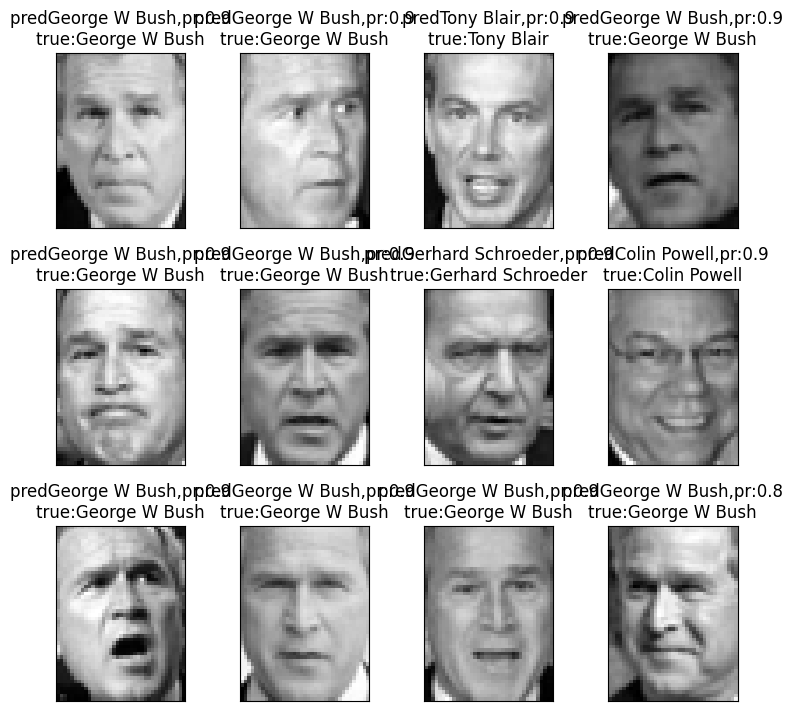

In [6]:
y_pred=[];y_prob=[]
for test_face in X_test_lda:
  prob=clf.predict_proba([test_face])[0]
  class_id=np.where(prob==np.max(prob))[0][0]
  y_pred.append(class_id)
  y_prob.append(np.max(prob))
y_pred=np.array(y_pred)
prediction_titles=[]
true_positive=0
for i in range(y_pred.shape[0]):
  true_name=class_names[y_test[i]]
  pred_name=class_names[y_pred[i]]
  result='pred%s,pr:%s\ntrue:%s'%(pred_name,str(y_prob[i])[0:3],true_name)
  prediction_titles.append(result)
  if true_name==pred_name:
    true_positive=true_positive+1
print("Accuracy:",true_positive*100/y_pred.shape[0])

# Uncommented plot_gallery for displaying predictions on image data.
plot_gallery(X_test,prediction_titles,h,w)
plt.show()